1. Importing Library

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from google_play_scraper import reviews_all, Sort

%matplotlib inline 
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
warnings.filterwarnings('ignore')

2. Data Loading & Exploration

In [10]:
tix_reviews = reviews_all(
    'id.tix.android',
    lang='id',
    country='id',
    sort=Sort.NEWEST
)

data = pd.DataFrame(tix_reviews)
data = data[['content', 'score', 'thumbsUpCount', 'at', 'appVersion']]
data.head()

,content,score,thumbsUpCount,at,appVersion
0,tes cek dulu,4,0,2026-04-06 15:01:24,4.5.0
1,"kota bitung gak ada,yg ada hanya manado",5,0,2026-04-06 12:41:05,4.5.0
2,dear developer aplikasi ini tolong updatean ba...,5,0,2026-04-06 11:10:27,4.5.0
3,sangat baik,5,0,2026-04-05 06:22:05,4.4.0
4,sangat bagus,5,0,2026-04-03 12:55:28,4.5.0


In [11]:
print(f"The number of rows in the dataset is {data.shape[0]}, and the number of columns is {data.shape[1]}.")

The number of rows in the dataset is 96274, and the number of columns is 5.


In [12]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 96274 entries, 0 to 96273
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   content        96274 non-null  str           
 1   score          96274 non-null  int64         
 2   thumbsUpCount  96274 non-null  int64         
 3   at             96274 non-null  datetime64[us]
 4   appVersion     85506 non-null  str           
dtypes: datetime64[us](1), int64(2), str(2)
memory usage: 3.7 MB


In [13]:
data.columns

Index(['content', 'score', 'thumbsUpCount', 'at', 'appVersion'], dtype='str')

In [14]:
data.describe()

,score,thumbsUpCount,at
count,96274.000000,96274.000000,96274
mean,4.452770,0.567744,2019-11-09 00:37:44.254482
min,1.000000,0.000000,2018-04-01 17:01:03
25%,5.000000,0.000000,2018-12-23 14:39:51.250000
50%,5.000000,0.000000,2019-05-02 12:42:42
75%,5.000000,0.000000,2019-10-09 15:17:49.500000
max,5.000000,1018.000000,2026-04-06 15:01:24
std,1.180296,10.390582,NaN


2.1 Cleaning and Wrangling

In [15]:
data.dropna(subset=['content'], inplace=True)

data['review_length'] = data['content'].apply(lambda x: len(str(x)))
data['at'] = pd.to_datetime(data['at'])

data["score"].unique()

array([4, 5, 3, 1, 2])

2.2 Missing Values

Missing values per column:
content              0
score                0
thumbsUpCount        0
at                   0
appVersion       10768
review_length        0
dtype: int64

Missing value percentage:
content           0.00
score             0.00
thumbsUpCount     0.00
at                0.00
appVersion       11.18
review_length     0.00
dtype: float64


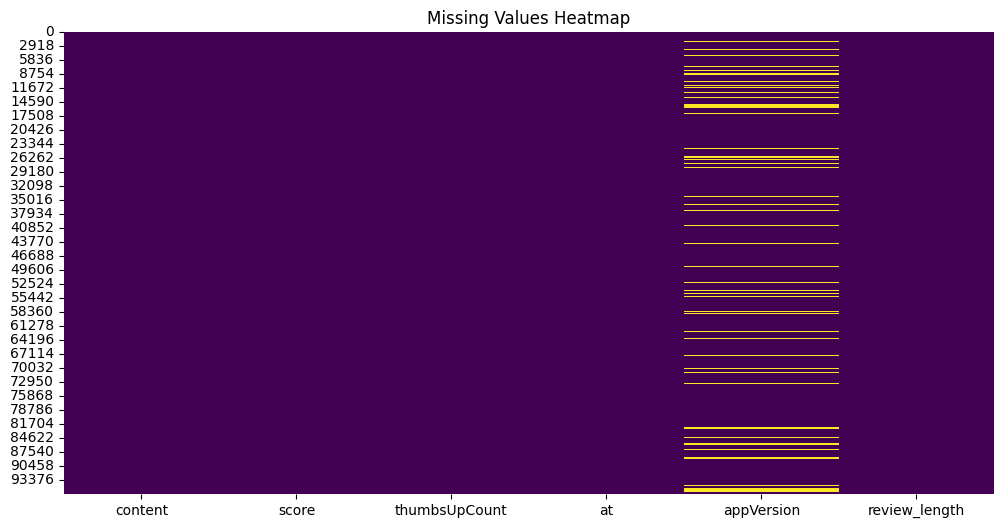

In [16]:
print("Missing values per column:")
print(data.isnull().sum())

print("\nMissing value percentage:")
print(round(data.isnull().sum()/data.shape[0]*100, 2))

plt.figure(figsize=(12, 6))
sns.heatmap(data.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

2.3 Dealing with the missing values & Duplicates

In [17]:
num_duplicates = data.duplicated().sum()
print(f"Number of duplicates in dataset: {num_duplicates}")

data.drop_duplicates(inplace=True)
print(f"Number of rows after removing duplicates: {data.shape[0]}")

data['appVersion'].fillna('Unknown', inplace=True)

Number of duplicates in dataset: 1
Number of rows after removing duplicates: 96273


0          4.5.0
1          4.5.0
2          4.5.0
3          4.4.0
4          4.5.0
5          4.5.0
6          4.5.0
7          4.5.0
8          4.5.0
9          4.5.0
10       Unknown
11         4.5.0
12         4.5.0
13         4.5.0
14         4.5.0
15         4.5.0
16         4.5.0
17         4.5.0
18       Unknown
19         4.5.0
20       Unknown
21         4.5.0
22         4.5.0
23         4.5.0
24         4.3.0
25       Unknown
26         4.5.0
27       Unknown
28         4.5.0
29       Unknown
30         4.5.0
31         4.5.0
32         4.5.0
33       Unknown
34         4.5.0
35         4.4.0
36         4.5.0
37         4.5.0
38       Unknown
39       Unknown
40         4.5.0
41         4.4.0
42       Unknown
43         4.4.0
44         4.4.0
45         4.4.0
46       Unknown
47         4.4.0
48         4.4.0
49         4.4.0
50         4.4.0
51         4.4.0
52         4.4.0
53         4.3.0
54       Unknown
55         4.4.0
56         4.3.0
57         4.3.0
58         4.4

2.4 Visual Analysis (EDA Insights)

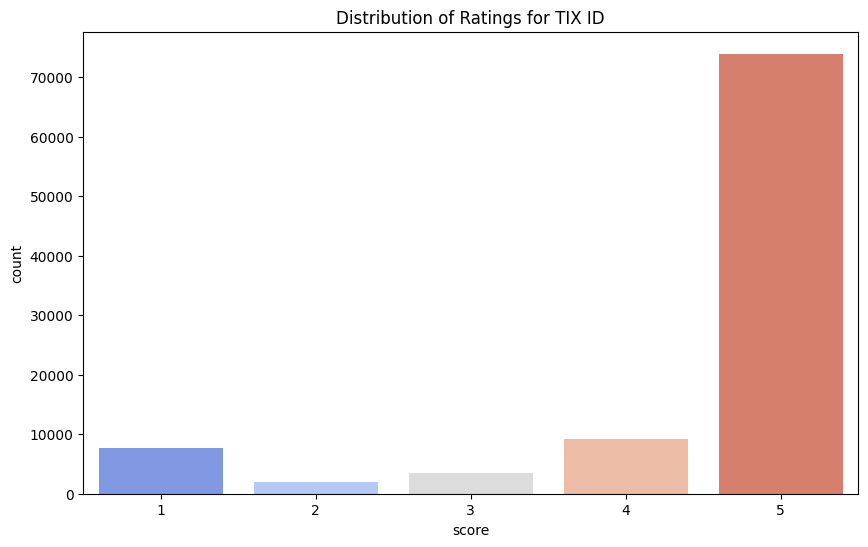

In [18]:
# Analisis Distribusi Rating
plt.figure(figsize=(10, 6))
sns.countplot(x='score', data=data, palette='coolwarm')
plt.title('Distribution of Ratings for TIX ID')
plt.show()

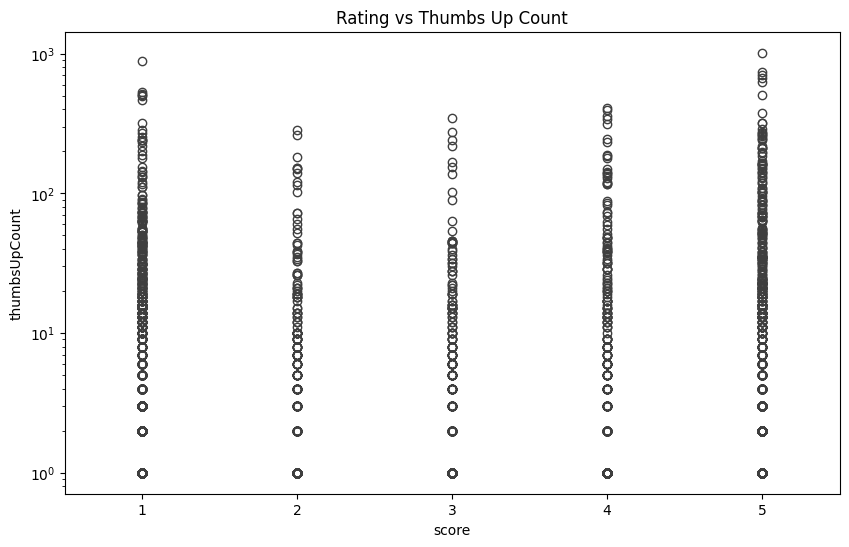

In [19]:
# Hubungan Rating vs Jumlah Thumbs Up (Persetujuan User Lain)
plt.figure(figsize=(10, 6))
sns.boxplot(x='score', y='thumbsUpCount', data=data)
plt.title('Rating vs Thumbs Up Count')
plt.yscale('log')
plt.show()

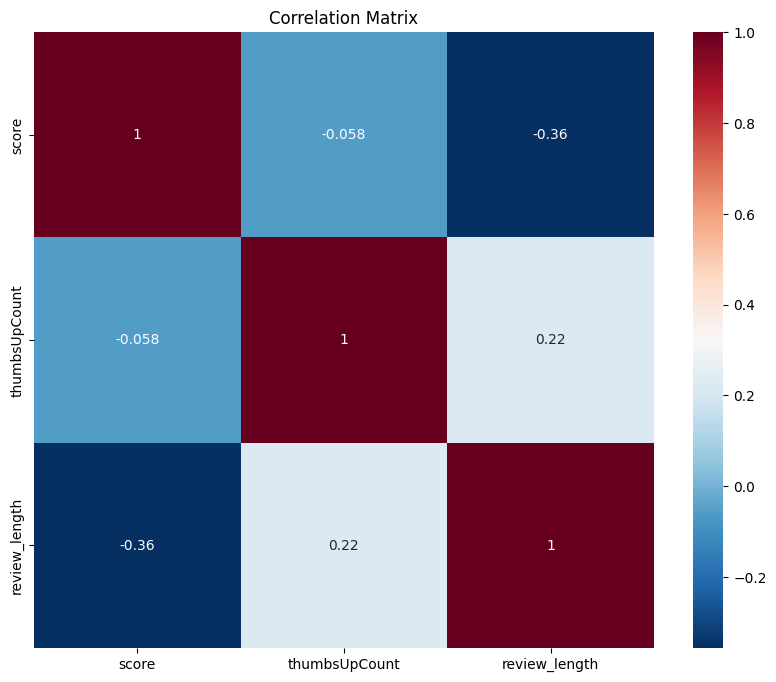

In [20]:
# Korelasi antar kolom numerik
plt.figure(figsize=(10, 8))
numeric_cols = data.select_dtypes(include=[np.number]).columns
sns.heatmap(data[numeric_cols].corr(), annot=True, cmap='RdBu_r')
plt.title('Correlation Matrix')
plt.show()